# Five-player Cournot game: direct-map DTB

This deterministic example follows Algorithm 1: advance the particle map values directly, keep the neural-map parameters fixed within each reset block, and refit the NN to the accumulated map at block boundaries.

With $b=2$, $\mu=7/4$, and $s_i=\sum_{j\ne i}x_j$, the game velocity is

$$F_i(x)=2b\left(\max\{\mu s_i(1-s_i),0\}-x_i\right).$$

Initial particles are uniform on $[0,1]^5$. Run all cells for the point clouds in $(x_1,x_2)$, $(x_2,x_3)$, $(x_3,x_4)$, and $(x_4,x_5)$, followed by the projection-error trajectory.

[Open in Colab](https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/DTB_Game_Ver2/cournot_5d_b2_mu7_4_parameter_evolving_dtb.ipynb)

In [1]:
from copy import deepcopy
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

# Use the existing helpers locally, or obtain them when running in Colab.
module_files = ('dtb.py', 'run_game_dtb.py')
module_dir = next((p for p in (Path.cwd(), Path.cwd() / 'DTB_Game_Ver2')
                   if all((p / name).is_file() for name in module_files)), None)
if module_dir is None:
    if not Path('/content').is_dir():
        raise FileNotFoundError('Run from the repository root or DTB_Game_Ver2.')
    repo = Path('/content/dtb-colab-experiments')
    if not repo.exists():
        subprocess.run([
            'git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
            'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo),
        ], check=True)
    module_dir = repo / 'DTB_Game_Ver2'
sys.path.insert(0, str(module_dir.resolve()))

from dtb import flat_params
from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices

## Parameters

The residual tanh MLP starts at the identity. Its parameters stay fixed for `REFIT_EVERY` particle updates. Select 128 tangent coordinates at each step, then refit all NN parameters to the current particle map every 100 steps. Set `REFIT_EVERY = 0` to disable resets.

In [2]:
SEED = 0
DIM = 5
COURNOT_B = 2.0
COURNOT_MU = 7 / 4
N_PARTICLES = 3000

H = 0.001
T_FINAL = 2.5
SNAPSHOT_TIMES = (0.0, 0.25, 0.5, T_FINAL)
WIDTH, DEPTH = 16, 2
BASIS_SIZE = 128
SVD_RTOL = 1e-6  # Retain singular values above SVD_RTOL * s_max.
JACOBIAN_CHUNK = 256
REFIT_EVERY = 100
REFIT_MAX_ITER = 500

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float64
torch.set_num_threads(min(4, torch.get_num_threads()))


def game_velocity(x):
    rivals = x.sum(dim=-1, keepdim=True) - x
    best_response = (COURNOT_MU * rivals * (1 - rivals)).clamp_min(0.0)
    return 2 * COURNOT_B * (best_response - x)

## Evolve the particle map

Keep the reference labels $z_i$ fixed. Store $x_i^k=X^k(z_i)$ independently of the NN and initialize $x_i^0=z_i$. In reset block $j$, freeze the fitted parameters $\bar\theta_j$ and select tangent coordinates $S_k$ at each step:

$$J_i^k=\partial_{\theta_{S_k}}T_{\bar\theta_j}(z_i),\qquad g_i^k=F(x_i^k).$$

For $A=J^k/\sqrt N=U\Sigma V^\top$ and $y=\operatorname{vec}(g^k)/\sqrt N$, keep $s_\ell>\texttt{SVD\_RTOL}\,s_{\max}$ and use the truncated-SVD solution

$$\alpha^k=V_{\rm keep}\Sigma_{\rm keep}^{-1}U_{\rm keep}^\top y,
\qquad x_i^{k+1}=x_i^k+h_kJ_i^k\alpha^k.$$

After each block, refit a copy of the current NN to $\{(z_i,x_i^{k+1})\}$ by minimizing $N^{-1}\sum_i\|T_\vartheta(z_i)-x_i^{k+1}\|_2^2$. The fitted parameters define the next tangent space. **Refitting leaves the stored particle values unchanged.** No parameter Euler update is performed. A reset also occurs at the final time when the step count is a multiple of the reset interval, as in Algorithm 1.

The error curve records $\|J^k\alpha^k-g^k\|/\sqrt N$ at the start of each particle step. Dotted lines mark the refits. Every point-cloud snapshot comes from the directly updated particle values.

In [3]:
def refit_map(model, z, x):
    target_map = x.detach().clone()
    fitted = deepcopy(model)  # Warm start from the previous block's fit.
    optimizer = torch.optim.LBFGS(
        fitted.parameters(), max_iter=REFIT_MAX_ITER, history_size=50,
        tolerance_grad=1e-10, tolerance_change=1e-12, line_search_fn='strong_wolfe')

    def closure():
        optimizer.zero_grad(set_to_none=True)
        loss = (fitted(z) - target_map).square().sum(dim=1).mean()
        loss.backward()
        return loss

    optimizer.step(closure)
    with torch.no_grad():
        loss = (fitted(z) - target_map).square().sum(dim=1).mean()
    if not torch.isfinite(loss):
        raise FloatingPointError('The NN refit produced a nonfinite loss.')
    return fitted


def new_basis(theta_bar, model, structure, z):
    indices = torch.randperm(theta_bar.numel(), generator=basis_generator)
    selected = indices[:BASIS_SIZE].sort().values.to(DEVICE)
    _, _, J_flat = game_dtb_basis_matrices(
        theta_bar, selected, z, model, structure, chunk=JACOBIAN_CHUNK)
    return J_flat.detach()


# Rerunning this cell restarts the same experiment from the identity map.
torch.manual_seed(SEED)
basis_generator = torch.Generator().manual_seed(SEED + 1)
z = torch.rand(N_PARTICLES, DIM, generator=torch.Generator().manual_seed(SEED),
               dtype=DTYPE).to(DEVICE)
x = z.clone()  # These are the actual X^k(z_i) values throughout the run.
model = ResidualMLPMap(dim=DIM, width=WIDTH, depth=DEPTH,
                       activation='tanh', dtype=DTYPE).to(DEVICE)
theta_bar, structure, _ = flat_params(model)
J_flat = new_basis(theta_bar, model, structure, z)

snapshot_times = np.unique(np.round(SNAPSHOT_TIMES, 12))
times = np.unique(np.round(np.r_[np.arange(0, T_FINAL, H), snapshot_times, T_FINAL], 12))
projection_times = times[:-1]
projection_error, refit_times = [], []
clouds = {0.0: x.cpu().numpy().copy()}

for k, t in enumerate(projection_times):
    velocity = game_velocity(x)
    A = J_flat / np.sqrt(N_PARTICLES)
    target = velocity.reshape(-1) / np.sqrt(N_PARTICLES)
    U, s, Vh = torch.linalg.svd(A, full_matrices=False)
    keep = s > SVD_RTOL * s[0]
    alpha = Vh[keep].T @ ((U[:, keep].T @ target) / s[keep])
    tangent_velocity = (J_flat @ alpha).reshape_as(x)
    error = (tangent_velocity - velocity).square().sum(dim=1).mean().sqrt()
    if not torch.isfinite(error):
        raise FloatingPointError(f'Nonfinite tangent projection at t={t:g}.')
    projection_error.append(error.item())

    next_time = float(times[k + 1])
    h = next_time - float(t)
    x = (x + h * tangent_velocity).detach()
    if not torch.isfinite(x).all():
        raise FloatingPointError(f'Nonfinite particle state at t={next_time:g}.')

    if REFIT_EVERY and (k + 1) % REFIT_EVERY == 0:
        model = refit_map(model, z, x)
        theta_bar, structure, _ = flat_params(model)
        refit_times.append(next_time)

    if next_time in snapshot_times:
        clouds[next_time] = x.cpu().numpy().copy()
    # Select the next S_k; a refit changes the NN whose Jacobian is used here.
    J_flat = new_basis(theta_bar, model, structure, z)

projection_error = np.asarray(projection_error)

## Point-cloud projections

Rows show the four adjacent coordinate pairs; columns show physical time. All particles are displayed, with common axis limits across the figure.

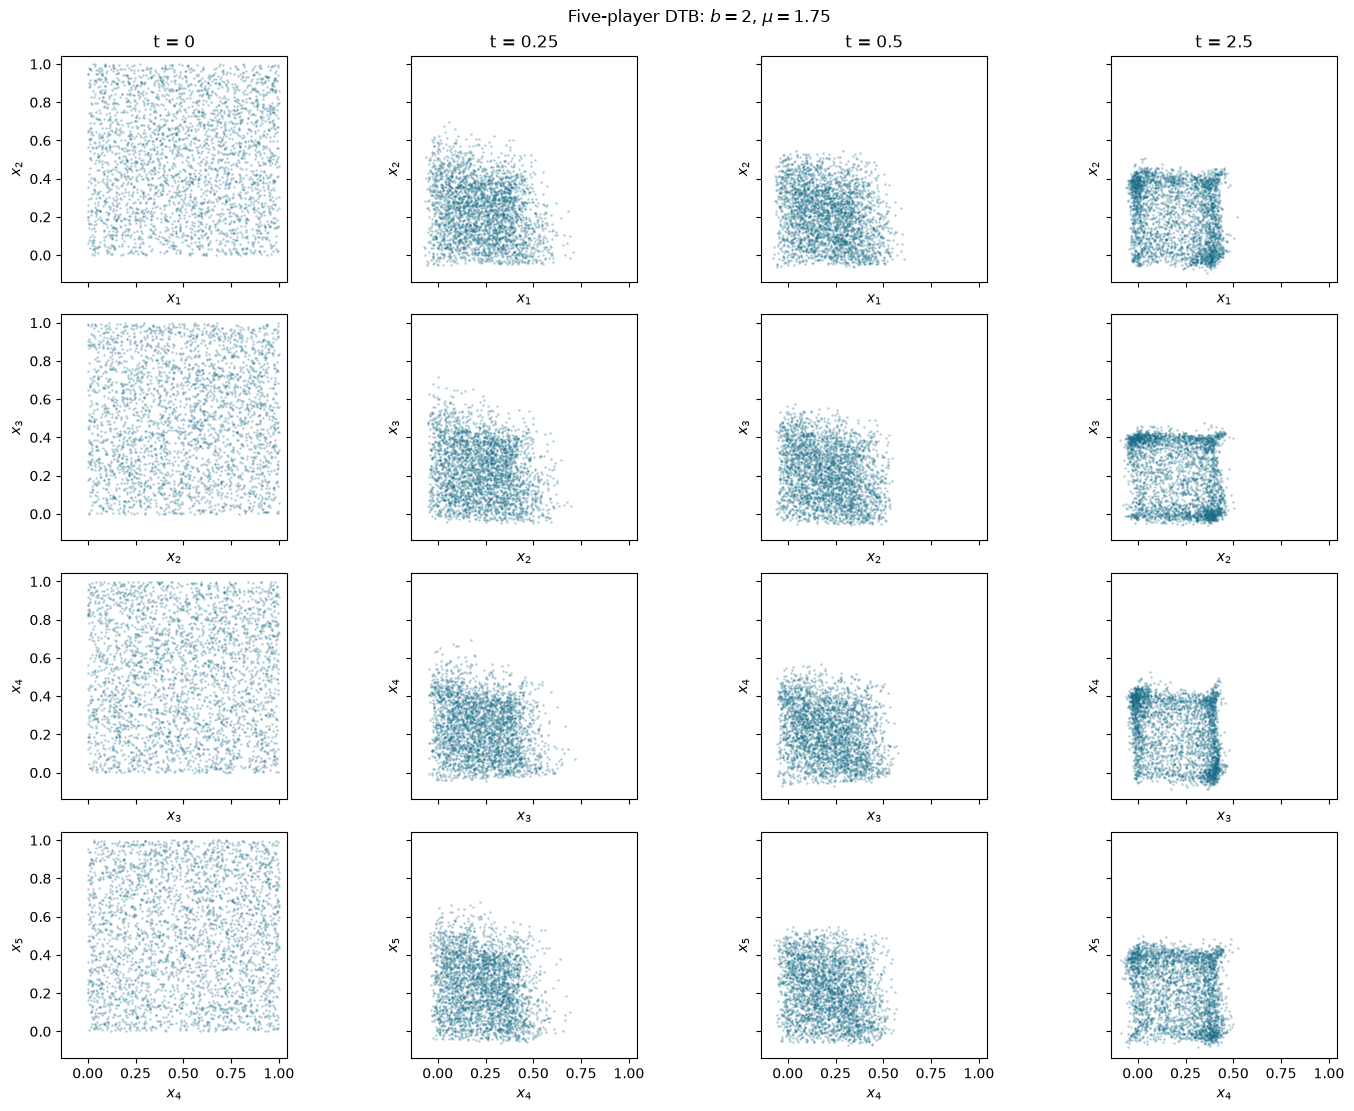

In [4]:
pairs = ((0, 1), (1, 2), (2, 3), (3, 4))
fig, axes = plt.subplots(4, len(clouds), figsize=(3.5 * len(clouds), 11),
                         sharex=True, sharey=True, squeeze=False, layout='constrained')
lo = min(points.min() for points in clouds.values())
hi = max(points.max() for points in clouds.values())
padding = 0.04 * max(hi - lo, 1e-6)

for row, (i, j) in enumerate(pairs):
    for col, (t, points) in enumerate(clouds.items()):
        ax = axes[row, col]
        ax.scatter(points[:, i], points[:, j], s=3, alpha=0.35,
                   color='#176b87', linewidths=0, rasterized=True)
        ax.set(xlabel=fr'$x_{i + 1}$', ylabel=fr'$x_{j + 1}$',
               xlim=(lo - padding, hi + padding), ylim=(lo - padding, hi + padding))
        ax.set_aspect('equal', adjustable='box')
        if row == 0:
            ax.set_title(f't = {t:g}')
fig.suptitle(fr'Five-player DTB: $b={COURNOT_B:g}$, $\mu={COURNOT_MU:g}$')
plt.show()

## Projection-error trajectory

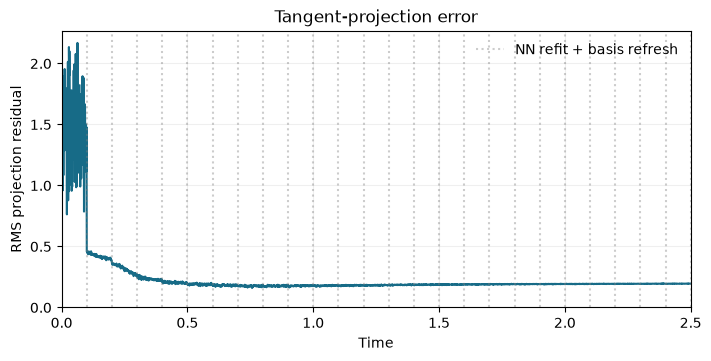

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5), layout='constrained')
ax.plot(projection_times, projection_error, color='#176b87', linewidth=1.5)
for index, t in enumerate(refit_times):
    ax.axvline(t, color='0.5', linestyle=':', alpha=0.4,
               label='NN refit + basis refresh' if index == 0 else None)
if refit_times:
    ax.legend(frameon=False)
ax.set(xlabel='Time', ylabel='RMS projection residual',
       title='Tangent-projection error', xlim=(0, T_FINAL), ylim=(0, None))
ax.grid(alpha=0.2)
plt.show()